# Capstone Project 1: Predicting Third Semester Retention — Course 3 Model Tournament

## Objective

This notebook walks through the **UPAD cycle** — **Understand, Prepare, Analyze, Deploy** — to build and compare advanced classification models for student success.

In Course 2, the capstone focused on a broad model tournament. In Course 3, we keep the same capstone structure but update the analysis to match the advanced modeling topics covered in this course.

By the end of this capstone, you will compare:

1. **Regularized Logistic Regression** using academic and demographic data  
2. **Decision Tree** using academic and demographic data  
3. **XGBoost** using academic and demographic data  
4. **XGBoost + Survey Data** using academic, demographic, and survey-text features  

You will also complete a light **unsupervised learning** analysis to explore natural student groupings before making a final model recommendation.

# Understand

A university's Student Success Center wants to improve its early warning system for identifying students who may not return for their third semester. The center already has academic and demographic data, and Course 3 introduces a new source of information: **survey data transformed into machine-learning-ready text features**.

The main stakeholder question is:

> Which model should the university use to identify students at risk of not returning for their third semester, and does adding survey data improve the model enough to justify the added complexity?

## Capstone Tasks

You will:

1. Load regular and survey-enhanced Course 3 datasets.
2. Create the binary target variable for third-semester departure.
3. Prepare aligned feature sets for regular models and the survey-enhanced model.
4. Train four models: Logistic Regression, Decision Tree, XGBoost, and XGBoost with Survey Data.
5. Evaluate the models using accuracy, precision, recall, F1 score, ROC-AUC, average precision, and calibration error.
6. Compare confusion matrices, ROC curves, precision-recall curves, and feature importance.
7. Use K-Means and PCA for a light unsupervised learning analysis.
8. Recommend a final model for stakeholders.

## Success Criteria

Because the positive class is **DEPARTED = 1**, recall and F1 score are especially important. A model with very high accuracy but poor recall may miss students who need support.

# Prepare

## Data Wrangling

#### **Step 1: Import Libraries and Locate the Data**


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Core libraries
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Display
from IPython.display import display

# Visualization
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Modeling
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve, silhouette_score
)

# XGBoost
try:
    from xgboost import XGBClassifier
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'])
    from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries imported successfully!')

Libraries imported successfully!


In [3]:
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/projects2/Applied-Data-Analytics-For-Higher-Education-Course-3/data")

required_files = [
    "training.csv",
    "testing.csv",
    "ML_SURVEY_MASTER_TRAIN.csv",
    "ML_SURVEY_MASTER_TEST.csv"
]

missing_files = [file for file in required_files if not (DATA_DIR / file).exists()]

if missing_files:
    raise FileNotFoundError(
        f"Missing files: {missing_files}\n"
        "Check that DATA_DIR points to the correct Course 3 data folder."
    )

print(f"Data directory found: {DATA_DIR}")

Data directory found: /content/drive/MyDrive/projects2/Applied-Data-Analytics-For-Higher-Education-Course-3/data


#### **Step 2: Load Regular and Survey-Enhanced Datasets**

We will load two versions of the Course 3 data:

- `training.csv` and `testing.csv`: regular academic and demographic files used for inspection and EDA.
- `ML_SURVEY_MASTER_TRAIN.csv` and `ML_SURVEY_MASTER_TEST.csv`: machine-learning-ready files that include regular features plus survey text principal components (`TEXT_PC1`, `TEXT_PC2`, etc.).

In [4]:
train_df = pd.read_csv(DATA_DIR / "training.csv")
test_df = pd.read_csv(DATA_DIR / "testing.csv")

survey_train_df = pd.read_csv(DATA_DIR / "ML_SURVEY_MASTER_TRAIN.csv")
survey_test_df = pd.read_csv(DATA_DIR / "ML_SURVEY_MASTER_TEST.csv")

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)
print("Survey training data shape:", survey_train_df.shape)
print("Survey testing data shape:", survey_test_df.shape)

Training data shape: (19844, 27)
Testing data shape: (5336, 27)
Survey training data shape: (19844, 53)
Survey testing data shape: (5336, 53)


#### **Step 3: Create the Target Variable**

The original outcome column is `SEM_3_STATUS`:

- `E` means the student was enrolled in the third semester.
- Any value other than `E` is treated as not enrolled.

We create a binary target variable:

- `DEPARTED = 1`: student did not return for the third semester.
- `DEPARTED = 0`: student returned for the third semester.

In [7]:
# Create binary target in all datasets
for df in [train_df, test_df, survey_train_df, survey_test_df]:
    df['DEPARTED'] = (df['SEM_3_STATUS'] != 'E').astype(int)

# Compare target distributions
train_target_counts = survey_train_df['DEPARTED'].value_counts().sort_index()
test_target_counts = survey_test_df['DEPARTED'].value_counts().sort_index()

target_summary = pd.DataFrame({
    'Training Count': train_target_counts,
    'Training Percent': train_target_counts / train_target_counts.sum(),
    'Testing Count': test_target_counts,
    'Testing Percent': test_target_counts / test_target_counts.sum()
})

target_summary.index = ['Enrolled / Returned (0)', 'Departed / Not Returned (1)']

display(target_summary.style.format({
    'Training Percent': '{:.2%}',
    'Testing Percent': '{:.2%}'
}))

,Training Count,Training Percent,Testing Count,Testing Percent
Enrolled / Returned (0),17207,86.71%,4516,84.63%
Departed / Not Returned (1),2637,13.29%,820,15.37%


#### **Step 4: Check Data Quality**

Before modeling, we check for duplicate records, missing values, and feature alignment between training and testing data.

In [8]:
quality_summary = pd.DataFrame({
    'Dataset': ['train_df', 'test_df', 'survey_train_df', 'survey_test_df'],
    'Rows': [len(train_df), len(test_df), len(survey_train_df), len(survey_test_df)],
    'Columns': [train_df.shape[1], test_df.shape[1], survey_train_df.shape[1], survey_test_df.shape[1]],
    'Duplicate Rows': [
        train_df.duplicated().sum(),
        test_df.duplicated().sum(),
        survey_train_df.duplicated().sum(),
        survey_test_df.duplicated().sum()
    ],
    'Missing Values': [
        train_df.isna().sum().sum(),
        test_df.isna().sum().sum(),
        survey_train_df.isna().sum().sum(),
        survey_test_df.isna().sum().sum()
    ]
})

display(quality_summary)

# Confirm that the survey train/test files have the same columns after target creation
train_only_cols = sorted(set(survey_train_df.columns) - set(survey_test_df.columns))
test_only_cols = sorted(set(survey_test_df.columns) - set(survey_train_df.columns))

print(f'Columns only in survey_train: {train_only_cols}')
print(f'Columns only in survey_test:  {test_only_cols}')

,Dataset,Rows,Columns,Duplicate Rows,Missing Values
0,train_df,19844,28,20,0
1,test_df,5336,28,0,0
2,survey_train_df,19844,54,4,0
3,survey_test_df,5336,54,0,0


Columns only in survey_train: []
Columns only in survey_test:  []


#### **Step 5: Define Regular and Survey Feature Sets**

The survey master files already contain aligned numeric features. We will create two feature sets:

1. **Base feature set**: academic and demographic variables only.
2. **Survey-enhanced feature set**: base variables plus `TEXT_PC` survey-text features.

This lets us isolate the effect of adding survey data.

In [9]:
TARGET_COL = 'DEPARTED'
STATUS_COL = 'SEM_3_STATUS'

# Survey text principal component features
survey_text_features = [col for col in survey_train_df.columns if col.startswith('TEXT_PC')]
survey_text_features = sorted(survey_text_features, key=lambda col: int(col.replace('TEXT_PC', '')))

# Base features exclude the target/status columns and survey text features
base_features = [
    col for col in survey_train_df.columns
    if col not in [STATUS_COL, TARGET_COL] + survey_text_features
]

# Survey-enhanced features include base features plus survey text features
survey_features = base_features + survey_text_features

print(f'Base feature count: {len(base_features)}')
print(f'Survey text feature count: {len(survey_text_features)}')
print(f'Survey-enhanced feature count: {len(survey_features)}')

print('\nBase features:')
print(base_features)

print('\nFirst 10 survey text features:')
print(survey_text_features[:10])

Base feature count: 19
Survey text feature count: 33
Survey-enhanced feature count: 52

Base features:
['HS_GPA', 'GPA_1', 'GPA_2', 'DFW_RATE_1', 'DFW_RATE_2', 'UNITS_ATTEMPTED_1', 'UNITS_ATTEMPTED_2', 'GENDER_Female', 'GENDER_Male', 'RACE_ETHNICITY_Asian', 'RACE_ETHNICITY_Black or African American', 'RACE_ETHNICITY_Hispanic', 'RACE_ETHNICITY_Nonresident alien', 'RACE_ETHNICITY_Other', 'RACE_ETHNICITY_Two or More Races', 'RACE_ETHNICITY_White', 'FIRST_GEN_STATUS_Continuing Generation', 'FIRST_GEN_STATUS_First Generation', 'FIRST_GEN_STATUS_Unknown']

First 10 survey text features:
['TEXT_PC1', 'TEXT_PC2', 'TEXT_PC3', 'TEXT_PC4', 'TEXT_PC5', 'TEXT_PC6', 'TEXT_PC7', 'TEXT_PC8', 'TEXT_PC9', 'TEXT_PC10']


#### **Step 6: Prepare Modeling Matrices**

We will use the official Course 3 training and testing files rather than creating a new random split. This keeps the capstone aligned with the course modules and ensures that all four models are evaluated on the same test set.

In [10]:
# Make sure feature columns are numeric and handle any missing values with training medians
for col in survey_features:
    survey_train_df[col] = pd.to_numeric(survey_train_df[col], errors='coerce')
    survey_test_df[col] = pd.to_numeric(survey_test_df[col], errors='coerce')

feature_medians = survey_train_df[survey_features].median()
survey_train_df[survey_features] = survey_train_df[survey_features].fillna(feature_medians)
survey_test_df[survey_features] = survey_test_df[survey_features].fillna(feature_medians)

# Base feature matrices
X_train_base = survey_train_df[base_features].copy()
X_test_base = survey_test_df[base_features].copy()

# Survey-enhanced feature matrices
X_train_survey = survey_train_df[survey_features].copy()
X_test_survey = survey_test_df[survey_features].copy()

# Shared target arrays
y_train = survey_train_df[TARGET_COL].copy()
y_test = survey_test_df[TARGET_COL].copy()

# Scale base features for Logistic Regression
base_scaler = StandardScaler()
X_train_base_scaled = base_scaler.fit_transform(X_train_base)
X_test_base_scaled = base_scaler.transform(X_test_base)

print(f'X_train_base shape:   {X_train_base.shape}')
print(f'X_test_base shape:    {X_test_base.shape}')
print(f'X_train_survey shape: {X_train_survey.shape}')
print(f'X_test_survey shape:  {X_test_survey.shape}')
print(f'y_train shape:        {y_train.shape}')
print(f'y_test shape:         {y_test.shape}')

X_train_base shape:   (19844, 19)
X_test_base shape:    (5336, 19)
X_train_survey shape: (19844, 52)
X_test_survey shape:  (5336, 52)
y_train shape:        (19844,)
y_test shape:         (5336,)


#### **Step 7: Exploratory Data Analysis**

Before training models, we inspect the departure rate overall and across key student groups. This helps us understand the institutional context behind the prediction task.

In [11]:
# Overall departure rate
overall_train_departure = train_df['DEPARTED'].mean()
overall_test_departure = test_df['DEPARTED'].mean()

print(f'Training departure rate: {overall_train_departure:.2%}')
print(f'Testing departure rate:  {overall_test_departure:.2%}')

# Departure rate by selected regular-data features
eda_features = ['FIRST_GEN_STATUS', 'GENDER', 'RACE_ETHNICITY']

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=[
        'Departure Rate by First-Generation Status',
        'Departure Rate by Gender',
        'Departure Rate by Race/Ethnicity'
    ]
)

for i, feature in enumerate(eda_features, start=1):
    rates = (
        train_df.groupby(feature)['DEPARTED']
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    fig.add_trace(
        go.Bar(x=rates[feature], y=rates['DEPARTED'], name=feature, showlegend=False),
        row=1,
        col=i
    )

fig.update_layout(
    title='Training Data Departure Rates by Student Group',
    height=500,
    width=1200
)
fig.update_yaxes(tickformat='.0%')
fig.show()

Training departure rate: 13.29%
Testing departure rate:  15.37%


In [12]:
# Survey text feature overview
survey_pc_summary = survey_train_df[survey_text_features].describe().T
survey_pc_summary = survey_pc_summary[['mean', 'std', 'min', 'max']]

print('Survey text principal component summary:')
display(survey_pc_summary.head(10).round(3))

# Compare the average absolute value of survey text PCs
pc_strength = survey_train_df[survey_text_features].abs().mean().sort_values(ascending=False).head(10)

fig = px.bar(
    pc_strength.reset_index(),
    x='index',
    y=0,
    labels={'index': 'Survey Text Principal Component', 0: 'Mean Absolute Value'},
    title='Top Survey Text Components by Average Magnitude'
)
fig.show()

Survey text principal component summary:


,mean,std,min,max
TEXT_PC1,0.0,0.204,-0.485,0.452
TEXT_PC2,0.0,0.196,-0.430,0.470
TEXT_PC3,0.0,0.193,-0.427,0.447
TEXT_PC4,-0.0,0.191,-0.462,0.550
TEXT_PC5,0.0,0.187,-0.453,0.484
TEXT_PC6,0.0,0.184,-0.308,0.576
TEXT_PC7,0.0,0.182,-0.303,0.441
TEXT_PC8,-0.0,0.181,-0.333,0.676
TEXT_PC9,-0.0,0.178,-0.411,0.460
TEXT_PC10,0.0,0.176,-0.413,0.430


# Analyze

## Model Tournament: Course 3 Comparison

We will now train the four required models. The first three models use the base academic and demographic feature set. The fourth model uses the survey-enhanced feature set.

In [13]:
# Containers for model tournament results
models = {}
model_feature_sets = {}
training_times = {}
predictions = {}
probabilities = {}

# Class imbalance ratio for XGBoost
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print(f'Negative class count: {negative_count:,}')
print(f'Positive class count: {positive_count:,}')
print(f'XGBoost scale_pos_weight: {scale_pos_weight:.3f}')

Negative class count: 17,207
Positive class count: 2,637
XGBoost scale_pos_weight: 6.525


#### **Step 8: Build Regularized Logistic Regression Model**

Logistic Regression is a strong baseline because it is fast, interpretable, and commonly used in institutional reporting. We use L2 regularization and class weighting to account for the imbalance between enrolled and departed students.

In [14]:
print('Training Regularized Logistic Regression...')
start_time = time.time()

logistic_model = LogisticRegression(
    penalty='l2',
    C=0.1,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

logistic_model.fit(X_train_base_scaled, y_train)
training_times['Regularized Logistic Regression'] = time.time() - start_time

models['Regularized Logistic Regression'] = logistic_model
model_feature_sets['Regularized Logistic Regression'] = 'base_scaled'

print(f"Training completed in {training_times['Regularized Logistic Regression']:.3f} seconds")

Training Regularized Logistic Regression...
Training completed in 0.060 seconds


#### **Step 9: Build Decision Tree Model**

A Decision Tree is easy to explain because it creates rule-based splits. It may not always be the highest-performing model, but it is useful when stakeholders need a transparent decision process.

In [15]:
print('Training Decision Tree...')
start_time = time.time()

decision_tree_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=40,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

decision_tree_model.fit(X_train_base, y_train)
training_times['Decision Tree'] = time.time() - start_time

models['Decision Tree'] = decision_tree_model
model_feature_sets['Decision Tree'] = 'base'

print(f"Training completed in {training_times['Decision Tree']:.3f} seconds")

Training Decision Tree...
Training completed in 0.066 seconds


#### **Step 10: Build XGBoost Model Without Survey Data**

XGBoost is a gradient-boosted tree model that can capture nonlinear patterns and feature interactions. This version uses the same base feature set as the Logistic Regression and Decision Tree models.

In [16]:
print('Training XGBoost without survey data...')
start_time = time.time()

xgb_base_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    n_jobs=2,
    random_state=RANDOM_STATE
)

xgb_base_model.fit(X_train_base, y_train)
training_times['XGBoost'] = time.time() - start_time

models['XGBoost'] = xgb_base_model
model_feature_sets['XGBoost'] = 'base'

print(f"Training completed in {training_times['XGBoost']:.3f} seconds")

Training XGBoost without survey data...
Training completed in 1.100 seconds


#### **Step 11: Build XGBoost Model With Survey Data**

This model uses the same XGBoost structure as the previous model but adds survey-text principal components. This is the key Course 3 extension: testing whether survey data adds predictive value beyond regular academic and demographic data.

In [17]:
print('Training XGBoost with survey data...')
start_time = time.time()

xgb_survey_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    n_jobs=2,
    random_state=RANDOM_STATE
)

xgb_survey_model.fit(X_train_survey, y_train)
training_times['XGBoost + Survey Data'] = time.time() - start_time

models['XGBoost + Survey Data'] = xgb_survey_model
model_feature_sets['XGBoost + Survey Data'] = 'survey'

print(f"Training completed in {training_times['XGBoost + Survey Data']:.3f} seconds")

Training XGBoost with survey data...
Training completed in 0.530 seconds


#### **Step 12: Review Model Training Summary**

All four models have now been trained. Before evaluating performance, we summarize which feature set each model used and how long training took.

In [18]:
training_summary = pd.DataFrame({
    'Model': list(models.keys()),
    'Feature Set': [model_feature_sets[name] for name in models.keys()],
    'Training Time (seconds)': [training_times[name] for name in models.keys()]
})

display(training_summary.style.format({'Training Time (seconds)': '{:.3f}'}))

,Model,Feature Set,Training Time (seconds)
0,Regularized Logistic Regression,base_scaled,0.060
1,Decision Tree,base,0.066
2,XGBoost,base,1.100
3,XGBoost + Survey Data,survey,0.530


#### **Step 13: Evaluate All Models**

We evaluate the models using multiple metrics because each metric answers a different stakeholder question:

- **Accuracy**: How often is the model correct overall?
- **Precision**: Of students flagged as departed, how many truly departed?
- **Recall**: Of students who truly departed, how many did the model catch?
- **F1 Score**: How well does the model balance precision and recall?
- **ROC-AUC**: How well does the model separate departed and enrolled students across thresholds?
- **Average Precision**: How strong is the model when the positive class is relatively rare?
- **Brier Score**: How well calibrated are the predicted probabilities? Lower is better.

In [19]:
def get_test_matrix(feature_set_name):
    """Return the correct test matrix for each model type."""
    if feature_set_name == 'base_scaled':
        return X_test_base_scaled
    if feature_set_name == 'base':
        return X_test_base
    if feature_set_name == 'survey':
        return X_test_survey
    raise ValueError(f'Unknown feature set: {feature_set_name}')


def evaluate_model(model_name, model, feature_set_name):
    """Evaluate a trained model and return a dictionary of metrics."""
    X_eval = get_test_matrix(feature_set_name)
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Average Precision': average_precision_score(y_test, y_prob),
        'Brier Score': brier_score_loss(y_test, y_prob),
        'Training Time (seconds)': training_times[model_name]
    }

# Evaluate every model
results = []
for model_name, model in models.items():
    results.append(evaluate_model(model_name, model, model_feature_sets[model_name]))

results_df = pd.DataFrame(results).set_index('Model')

print('=' * 100)
print('COURSE 3 MODEL TOURNAMENT RESULTS')
print('=' * 100)
display(results_df.round(4))

COURSE 3 MODEL TOURNAMENT RESULTS


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision,Brier Score,Training Time (seconds)
Model,,,,,,,,
Regularized Logistic Regression,0.8306,0.4662,0.7073,0.5620,0.8370,0.6385,0.1439,0.0602
Decision Tree,0.8862,0.6122,0.7085,0.6569,0.8556,0.7361,0.1069,0.0655
XGBoost,0.8960,0.6426,0.7280,0.6827,0.8763,0.7608,0.1038,1.1002
XGBoost + Survey Data,0.8941,0.6364,0.7256,0.6781,0.8743,0.7584,0.1041,0.5296


In [20]:
# Print classification reports for detailed class-level performance
for model_name in results_df.index:
    print('=' * 80)
    print(model_name)
    print('=' * 80)
    print(classification_report(
        y_test,
        predictions[model_name],
        target_names=['Enrolled / Returned', 'Departed / Not Returned'],
        zero_division=0
    ))

Regularized Logistic Regression
                         precision    recall  f1-score   support

    Enrolled / Returned       0.94      0.85      0.89      4516
Departed / Not Returned       0.47      0.71      0.56       820

               accuracy                           0.83      5336
              macro avg       0.70      0.78      0.73      5336
           weighted avg       0.87      0.83      0.84      5336

Decision Tree
                         precision    recall  f1-score   support

    Enrolled / Returned       0.95      0.92      0.93      4516
Departed / Not Returned       0.61      0.71      0.66       820

               accuracy                           0.89      5336
              macro avg       0.78      0.81      0.79      5336
           weighted avg       0.89      0.89      0.89      5336

XGBoost
                         precision    recall  f1-score   support

    Enrolled / Returned       0.95      0.93      0.94      4516
Departed / Not Returned      

#### **Step 14: Visualize Model Performance**

The bar chart below compares the four models across the main performance metrics. Recall and F1 score are especially important because the institution wants to identify students who may need support.

In [21]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

fig = go.Figure()
for model_name in results_df.index:
    fig.add_trace(go.Bar(
        name=model_name,
        x=metrics_to_plot,
        y=[results_df.loc[model_name, metric] for metric in metrics_to_plot]
    ))

fig.update_layout(
    title='Course 3 Model Tournament: Performance Comparison',
    xaxis_title='Metric',
    yaxis_title='Score',
    barmode='group',
    height=500,
    width=1000,
    yaxis=dict(range=[0, 1])
)
fig.show()

#### **Step 15: Compare ROC and Precision-Recall Curves**

ROC curves show how well each model separates classes across thresholds. Precision-recall curves are especially useful when the positive class is less common, as it is here.

In [22]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=('ROC Curves', 'Precision-Recall Curves')
)

for model_name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    fig.add_trace(
        go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{model_name} ROC'),
        row=1,
        col=1
    )
    fig.add_trace(
        go.Scatter(x=recall, y=precision, mode='lines', name=f'{model_name} PR'),
        row=1,
        col=2
    )

fig.add_trace(
    go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random Baseline', line=dict(dash='dash')),
    row=1,
    col=1
)

baseline_precision = y_test.mean()
fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[baseline_precision, baseline_precision],
        mode='lines',
        name='Positive Class Baseline',
        line=dict(dash='dash')
    ),
    row=1,
    col=2
)

fig.update_xaxes(title_text='False Positive Rate', row=1, col=1)
fig.update_yaxes(title_text='True Positive Rate', row=1, col=1)
fig.update_xaxes(title_text='Recall', row=1, col=2)
fig.update_yaxes(title_text='Precision', row=1, col=2)

fig.update_layout(
    title='ROC and Precision-Recall Curve Comparison',
    height=500,
    width=1100
)
fig.show()

#### **Step 16: Compare Confusion Matrices**

Confusion matrices help stakeholders understand the practical consequences of each model:

- **True Negatives**: correctly identified enrolled students.
- **False Positives**: enrolled students incorrectly flagged as departed.
- **False Negatives**: departed students missed by the model.
- **True Positives**: departed students correctly flagged for possible support.

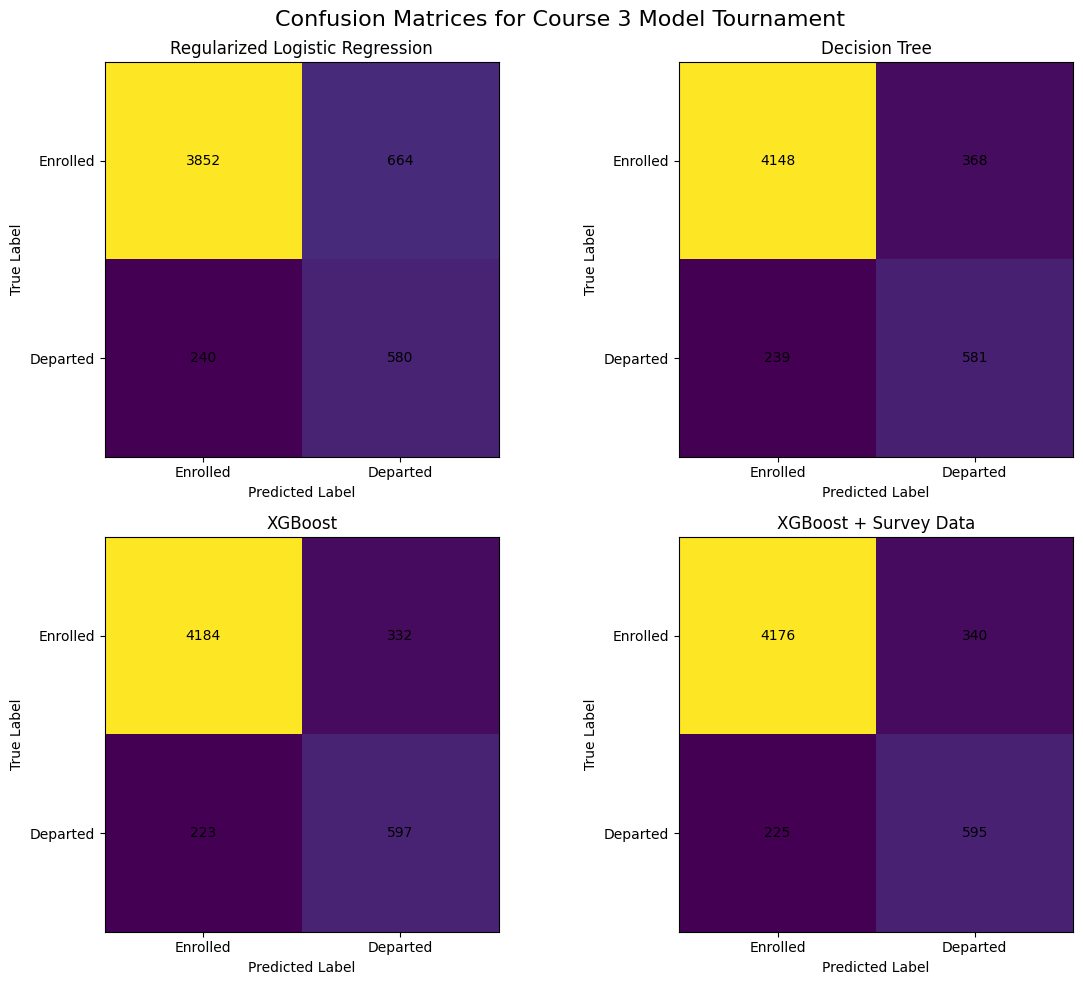

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, model_name in zip(axes, results_df.index):
    cm = confusion_matrix(y_test, predictions[model_name])
    im = ax.imshow(cm)
    ax.set_title(model_name)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Enrolled', 'Departed'])
    ax.set_yticklabels(['Enrolled', 'Departed'])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center')

plt.suptitle('Confusion Matrices for Course 3 Model Tournament', fontsize=16)
plt.tight_layout()
plt.show()

#### **Step 17: Compare Feature Importance**

Feature importance helps explain what each model is using to make predictions. Logistic Regression uses coefficient size, while the tree-based models use feature importance from their fitted trees.

In [24]:
def get_feature_importance(model_name, top_n=12):
    """Return the top feature importances for the selected model."""
    model = models[model_name]

    if model_feature_sets[model_name] == 'survey':
        feature_names = survey_features
    else:
        feature_names = base_features

    if model_name == 'Regularized Logistic Regression':
        importances = np.abs(model.coef_[0])
    else:
        importances = model.feature_importances_

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(top_n)

    return importance_df

importance_tables = {}
for model_name in results_df.index:
    importance_tables[model_name] = get_feature_importance(model_name, top_n=12)
    print(f'\nTop features for {model_name}:')
    display(importance_tables[model_name].round(4))


Top features for Regularized Logistic Regression:


,Feature,Importance
3,DFW_RATE_1,0.6945
4,DFW_RATE_2,0.4685
6,UNITS_ATTEMPTED_2,0.2238
1,GPA_1,0.2069
5,UNITS_ATTEMPTED_1,0.1502
15,RACE_ETHNICITY_White,0.1075
9,RACE_ETHNICITY_Asian,0.0928
2,GPA_2,0.0725
14,RACE_ETHNICITY_Two or More Races,0.0573
13,RACE_ETHNICITY_Other,0.0372



Top features for Decision Tree:


,Feature,Importance
3,DFW_RATE_1,0.4978
2,GPA_2,0.2610
4,DFW_RATE_2,0.1157
6,UNITS_ATTEMPTED_2,0.0582
1,GPA_1,0.0298
0,HS_GPA,0.0165
5,UNITS_ATTEMPTED_1,0.0099
9,RACE_ETHNICITY_Asian,0.0036
8,GENDER_Male,0.0030
11,RACE_ETHNICITY_Hispanic,0.0022



Top features for XGBoost:


,Feature,Importance
3,DFW_RATE_1,0.4902
1,GPA_1,0.1365
4,DFW_RATE_2,0.0886
2,GPA_2,0.0824
6,UNITS_ATTEMPTED_2,0.0348
9,RACE_ETHNICITY_Asian,0.0176
13,RACE_ETHNICITY_Other,0.0167
17,FIRST_GEN_STATUS_First Generation,0.0166
15,RACE_ETHNICITY_White,0.0163
14,RACE_ETHNICITY_Two or More Races,0.0149



Top features for XGBoost + Survey Data:


,Feature,Importance
3,DFW_RATE_1,0.4036
1,GPA_1,0.0852
2,GPA_2,0.0628
4,DFW_RATE_2,0.0521
6,UNITS_ATTEMPTED_2,0.0253
17,FIRST_GEN_STATUS_First Generation,0.0130
49,TEXT_PC31,0.0126
44,TEXT_PC26,0.0118
33,TEXT_PC15,0.0113
15,RACE_ETHNICITY_White,0.0112


In [25]:
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=list(results_df.index)
)

positions = [(1, 1), (1, 2), (2, 1), (2, 2)]

for model_name, position in zip(results_df.index, positions):
    top_features = importance_tables[model_name].sort_values('Importance')
    fig.add_trace(
        go.Bar(
            x=top_features['Importance'],
            y=top_features['Feature'],
            orientation='h',
            showlegend=False
        ),
        row=position[0],
        col=position[1]
    )

fig.update_layout(
    title='Top Feature Importance by Model',
    height=900,
    width=1100
)
fig.show()

#### **Step 18: Survey Data Impact Analysis**

The key Course 3 question is whether adding survey data improves the XGBoost model. We compare XGBoost without survey data to XGBoost with survey data.

In [26]:
survey_impact_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'Average Precision', 'Brier Score']

survey_impact = pd.DataFrame({
    'XGBoost': results_df.loc['XGBoost', survey_impact_metrics],
    'XGBoost + Survey Data': results_df.loc['XGBoost + Survey Data', survey_impact_metrics]
})

survey_impact['Difference'] = survey_impact['XGBoost + Survey Data'] - survey_impact['XGBoost']

print('Impact of adding survey data to XGBoost:')
display(survey_impact.round(4))

survey_features_in_top = [
    feature for feature in importance_tables['XGBoost + Survey Data']['Feature']
    if feature.startswith('TEXT_PC')
]

print('\nSurvey text features appearing in the top XGBoost + Survey Data importance list:')
print(survey_features_in_top if survey_features_in_top else 'No survey text features appeared in the top importance list.')

Impact of adding survey data to XGBoost:


,XGBoost,XGBoost + Survey Data,Difference
Accuracy,0.8960,0.8941,-0.0019
Precision,0.6426,0.6364,-0.0063
Recall,0.7280,0.7256,-0.0024
F1 Score,0.6827,0.6781,-0.0046
ROC-AUC,0.8763,0.8743,-0.0020
Average Precision,0.7608,0.7584,-0.0024
Brier Score,0.1038,0.1041,0.0004



Survey text features appearing in the top XGBoost + Survey Data importance list:
['TEXT_PC31', 'TEXT_PC26', 'TEXT_PC15', 'TEXT_PC8']


#### **Step 19: Unsupervised Learning Extension — Student Support Profiles**

Supervised learning predicts a known outcome. Unsupervised learning asks a different question:

> What natural groups of students appear in the data, even before we use the target label?

Here, we use **K-Means clustering** and **PCA visualization** to explore student profiles. This section is not used to select the winning predictive model, but it can help stakeholders think about different support strategies.

In [27]:
# Scale survey-enhanced features for clustering
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_train_survey)

# Compare several values of k using a reproducible sample.
# This keeps the capstone fast while still showing the correct unsupervised learning workflow.
cluster_sample_size = min(4000, X_cluster_scaled.shape[0])
cluster_rng = np.random.default_rng(RANDOM_STATE)
cluster_sample_index = cluster_rng.choice(
    X_cluster_scaled.shape[0],
    size=cluster_sample_size,
    replace=False
)
X_cluster_sample = X_cluster_scaled[cluster_sample_index]

k_values = range(2, 7)
cluster_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=5, random_state=RANDOM_STATE)
    sample_labels = kmeans.fit_predict(X_cluster_sample)
    score = silhouette_score(X_cluster_sample, sample_labels)
    cluster_results.append({'k': k, 'Silhouette Score': score})

cluster_results_df = pd.DataFrame(cluster_results)
display(cluster_results_df.round(4))

best_k = int(cluster_results_df.sort_values('Silhouette Score', ascending=False).iloc[0]['k'])
print(f'Selected k based on highest sample silhouette score: {best_k}')
print(f'Cluster selection sample size: {cluster_sample_size:,} students')

,k,Silhouette Score
0,2,0.0993
1,3,0.0359
2,4,0.0299
3,5,0.0471
4,6,0.0410


Selected k based on highest sample silhouette score: 2
Cluster selection sample size: 4,000 students


In [28]:
# Fit final K-Means model on the same reproducible sample used for cluster selection.
# For capstone purposes, this keeps the unsupervised analysis fast and easy to run.
kmeans_final = KMeans(n_clusters=best_k, n_init=5, random_state=RANDOM_STATE)
cluster_labels = kmeans_final.fit_predict(X_cluster_sample)

# PCA for two-dimensional visualization of the clustered sample
pca = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_pca = pca.fit_transform(X_cluster_sample)

cluster_viz_df = pd.DataFrame({
    'PCA 1': cluster_pca[:, 0],
    'PCA 2': cluster_pca[:, 1],
    'Cluster': cluster_labels.astype(str),
    'Departed': y_train.iloc[cluster_sample_index].map({0: 'Enrolled / Returned', 1: 'Departed / Not Returned'}).values
})

fig = px.scatter(
    cluster_viz_df,
    x='PCA 1',
    y='PCA 2',
    color='Cluster',
    symbol='Departed',
    opacity=0.65,
    title='K-Means Student Support Profiles Visualized with PCA'
)
fig.update_layout(height=600, width=900)
fig.show()

print(f'PCA component 1 explained variance: {pca.explained_variance_ratio_[0]:.2%}')
print(f'PCA component 2 explained variance: {pca.explained_variance_ratio_[1]:.2%}')
print(f'Total explained variance shown: {pca.explained_variance_ratio_.sum():.2%}')
print(f'Clustered sample size: {cluster_sample_size:,} students')

PCA component 1 explained variance: 7.17%
PCA component 2 explained variance: 4.60%
Total explained variance shown: 11.77%
Clustered sample size: 4,000 students


In [29]:
# Profile clusters using interpretable academic features and the target rate
cluster_profile_df = X_train_survey.iloc[cluster_sample_index].copy()
cluster_profile_df['Cluster'] = cluster_labels
cluster_profile_df['DEPARTED'] = y_train.iloc[cluster_sample_index].values

profile_columns = [
    'HS_GPA', 'GPA_1', 'GPA_2',
    'DFW_RATE_1', 'DFW_RATE_2',
    'UNITS_ATTEMPTED_1', 'UNITS_ATTEMPTED_2',
    'DEPARTED'
]

available_profile_columns = [col for col in profile_columns if col in cluster_profile_df.columns]

cluster_profile = cluster_profile_df.groupby('Cluster')[available_profile_columns].mean()
cluster_profile['Student Count'] = cluster_profile_df.groupby('Cluster').size()
cluster_profile['Departure Rate'] = cluster_profile['DEPARTED']
cluster_profile = cluster_profile.drop(columns=['DEPARTED'])

print('Cluster profiles based on the reproducible clustering sample:')
display(cluster_profile.round(3))

Cluster profiles based on the reproducible clustering sample:


,HS_GPA,GPA_1,GPA_2,DFW_RATE_1,DFW_RATE_2,UNITS_ATTEMPTED_1,UNITS_ATTEMPTED_2,Student Count,Departure Rate
Cluster,,,,,,,,,
0,0.753,0.848,0.834,0.024,0.031,0.151,0.191,2813,0.060
1,0.574,0.500,0.483,0.343,0.398,-0.465,-0.439,1187,0.302


##### Reflection Questions: Unsupervised Learning

Use the cluster profile table and PCA visualization to answer:

1. Which cluster appears to have the highest departure risk?
2. Which academic or survey-enhanced patterns seem to distinguish that cluster?
3. How could the Student Success Center use clusters to design different support strategies?
4. Why should clustering not be used as the only basis for high-stakes student decisions?

#### **Step 20: Model Selection — Determine the Tournament Winner**

The final decision should consider both predictive performance and institutional usability. We rank models using ROC-AUC, F1 score, recall, and precision. The best model is not always the most complex model; it is the model that best fits the stakeholder goal.

In [30]:
ranking_metrics = ['ROC-AUC', 'F1 Score', 'Recall', 'Precision']
ranking_df = results_df[ranking_metrics].copy()

for metric in ranking_metrics:
    ranking_df[f'{metric} Rank'] = ranking_df[metric].rank(ascending=False, method='min')

rank_columns = [f'{metric} Rank' for metric in ranking_metrics]
ranking_df['Average Rank'] = ranking_df[rank_columns].mean(axis=1)
ranking_df = ranking_df.sort_values('Average Rank')

tournament_winner = ranking_df.index[0]

print('=' * 90)
print('FINAL MODEL RANKINGS')
print('=' * 90)
display(ranking_df.round(4))

print(f'\nTournament winner based on average rank: {tournament_winner}')

FINAL MODEL RANKINGS


,ROC-AUC,F1 Score,Recall,Precision,ROC-AUC Rank,F1 Score Rank,Recall Rank,Precision Rank,Average Rank
Model,,,,,,,,,
XGBoost,0.8763,0.6827,0.7280,0.6426,1.0,1.0,1.0,1.0,1.0
XGBoost + Survey Data,0.8743,0.6781,0.7256,0.6364,2.0,2.0,2.0,2.0,2.0
Decision Tree,0.8556,0.6569,0.7085,0.6122,3.0,3.0,3.0,3.0,3.0
Regularized Logistic Regression,0.8370,0.5620,0.7073,0.4662,4.0,4.0,4.0,4.0,4.0



Tournament winner based on average rank: XGBoost


In [31]:
# Identify best model by each individual metric
print('Best model by each metric:')
for metric in ranking_metrics:
    best_model = results_df[metric].idxmax()
    best_score = results_df.loc[best_model, metric]
    print(f'  {metric}: {best_model} ({best_score:.4f})')

# Compare survey-enhanced model against the base XGBoost model
xgb_f1_change = results_df.loc['XGBoost + Survey Data', 'F1 Score'] - results_df.loc['XGBoost', 'F1 Score']
xgb_auc_change = results_df.loc['XGBoost + Survey Data', 'ROC-AUC'] - results_df.loc['XGBoost', 'ROC-AUC']

print('\nSurvey-enhanced XGBoost lift:')
print(f'  F1 Score change: {xgb_f1_change:+.4f}')
print(f'  ROC-AUC change:  {xgb_auc_change:+.4f}')

Best model by each metric:
  ROC-AUC: XGBoost (0.8763)
  F1 Score: XGBoost (0.6827)
  Recall: XGBoost (0.7280)
  Precision: XGBoost (0.6426)

Survey-enhanced XGBoost lift:
  F1 Score change: -0.0046
  ROC-AUC change:  -0.0020


# Deploy

#### **Step 21: Create Stakeholder Summary**

This final section turns the technical analysis into a stakeholder-ready summary. The recommendation should explain both model performance and practical implications for student support.

In [32]:
best_model_metrics = results_df.loc[tournament_winner]

print('=' * 90)
print('EXECUTIVE SUMMARY: COURSE 3 CAPSTONE PROJECT 1')
print('=' * 90)
print(f'Recommended model: {tournament_winner}')
print('\nRecommended model performance:')
print(f"  Accuracy:          {best_model_metrics['Accuracy']:.3f}")
print(f"  Precision:         {best_model_metrics['Precision']:.3f}")
print(f"  Recall:            {best_model_metrics['Recall']:.3f}")
print(f"  F1 Score:          {best_model_metrics['F1 Score']:.3f}")
print(f"  ROC-AUC:           {best_model_metrics['ROC-AUC']:.3f}")
print(f"  Average Precision: {best_model_metrics['Average Precision']:.3f}")
print(f"  Brier Score:       {best_model_metrics['Brier Score']:.3f}")

print('\nInterpretation guidance:')
print('- Recall shows how many truly departed students the model successfully identified.')
print('- Precision shows how many flagged students were truly departed.')
print('- ROC-AUC shows overall separation between enrolled and departed students.')
print('- Brier Score shows probability calibration, where lower is better.')
print('- Survey data should be adopted only if the performance gain is meaningful and ethically justified.')

EXECUTIVE SUMMARY: COURSE 3 CAPSTONE PROJECT 1
Recommended model: XGBoost

Recommended model performance:
  Accuracy:          0.896
  Precision:         0.643
  Recall:            0.728
  F1 Score:          0.683
  ROC-AUC:           0.876
  Average Precision: 0.761
  Brier Score:       0.104

Interpretation guidance:
- Recall shows how many truly departed students the model successfully identified.
- Precision shows how many flagged students were truly departed.
- ROC-AUC shows overall separation between enrolled and departed students.
- Brier Score shows probability calibration, where lower is better.
- Survey data should be adopted only if the performance gain is meaningful and ethically justified.


#### **Step 22: Produce a Comprehensive Report on Your Findings**

Using the analyses above, write a stakeholder report that addresses the following:

1. **Problem Summary**  
   Explain the institutional goal and why third-semester retention matters.

2. **Data Summary**  
   Describe the regular academic/demographic data and the survey-enhanced data.

3. **Model Comparison**  
   Compare Logistic Regression, Decision Tree, XGBoost, and XGBoost + Survey Data.

4. **Survey Data Impact**  
   Explain whether survey data improved model performance and whether the improvement is large enough to justify using survey information.

5. **Unsupervised Learning Insight**  
   Summarize what the cluster analysis revealed about student support profiles.

6. **Recommended Model**  
   Identify the model you recommend and justify your choice using metrics and stakeholder needs.

7. **Ethical and Practical Considerations**  
   Discuss privacy, fairness, interpretability, and how predictions should support—not replace—human advising.